## Mask Analysis

In [29]:
# Imports 
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [16]:
# Variables

WORK_DIR = f"../work_dirs/cracks_augmentation"
PRED_DIR = f"{WORK_DIR}/results/masks/"
GT_DIR = f"../data/2026-01-19-defect_dataset/labels_cracks"

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- CONFIGURATION ---
# Define which pixel values count as "Cracks"
# You have 0=Background, 1=Simple, 2=Alligator, 3=Severe
DEFECT_CLASSES = [1, 2, 3] 

def generate_error_heatmap(y_true, y_pred, filename):
    
    # 1. Flatten Multi-Class to Binary (Defect vs Background)
    # np.isin checks if the pixel value is in our list of defects [1, 2, 3]
    gt_binary = np.isin(y_true, DEFECT_CLASSES).astype(np.uint8)
    pred_binary = np.isin(y_pred, DEFECT_CLASSES).astype(np.uint8)

    # 2. Generate the Heatmap Layers
    # GREEN: True Positive (Model and GT both agree there is a crack)
    tp = np.logical_and(pred_binary == 1, gt_binary == 1)
    
    # RED: False Positive (Model hallucinated a crack in empty space)
    fp = np.logical_and(pred_binary == 1, gt_binary == 0)
    
    # BLUE: False Negative (Model missed the crack completely)
    fn = np.logical_and(pred_binary == 0, gt_binary == 1)

    # 3. Build the RGB Image
    h, w = y_true.shape
    heatmap = np.zeros((h, w, 3), dtype=np.uint8)
    
    heatmap[tp] = [0, 255, 0]   # Green = Good match
    heatmap[fp] = [255, 0, 0]   # Red = "Ghost" crack (Noise)
    heatmap[fn] = [0, 0, 255]   # Blue = Missed crack

    # 4. Display It
    plt.figure(figsize=(10, 8))
    plt.imshow(heatmap)
    plt.title(f"Error Heatmap: {filename}\n(Green=Correct, Red=Noise, Blue=Missed)")
    plt.axis('off')
    plt.show()

# --- EXAMPLE USAGE IN YOUR LOOP ---
# Assuming 'gt_img' and 'pred_img' are loaded as grayscale (0-255)
# generate_error_heatmap(gt_img, pred_img, "Test_Image_01")

Found 100 prediction masks.

Total Pairs Processed: 30


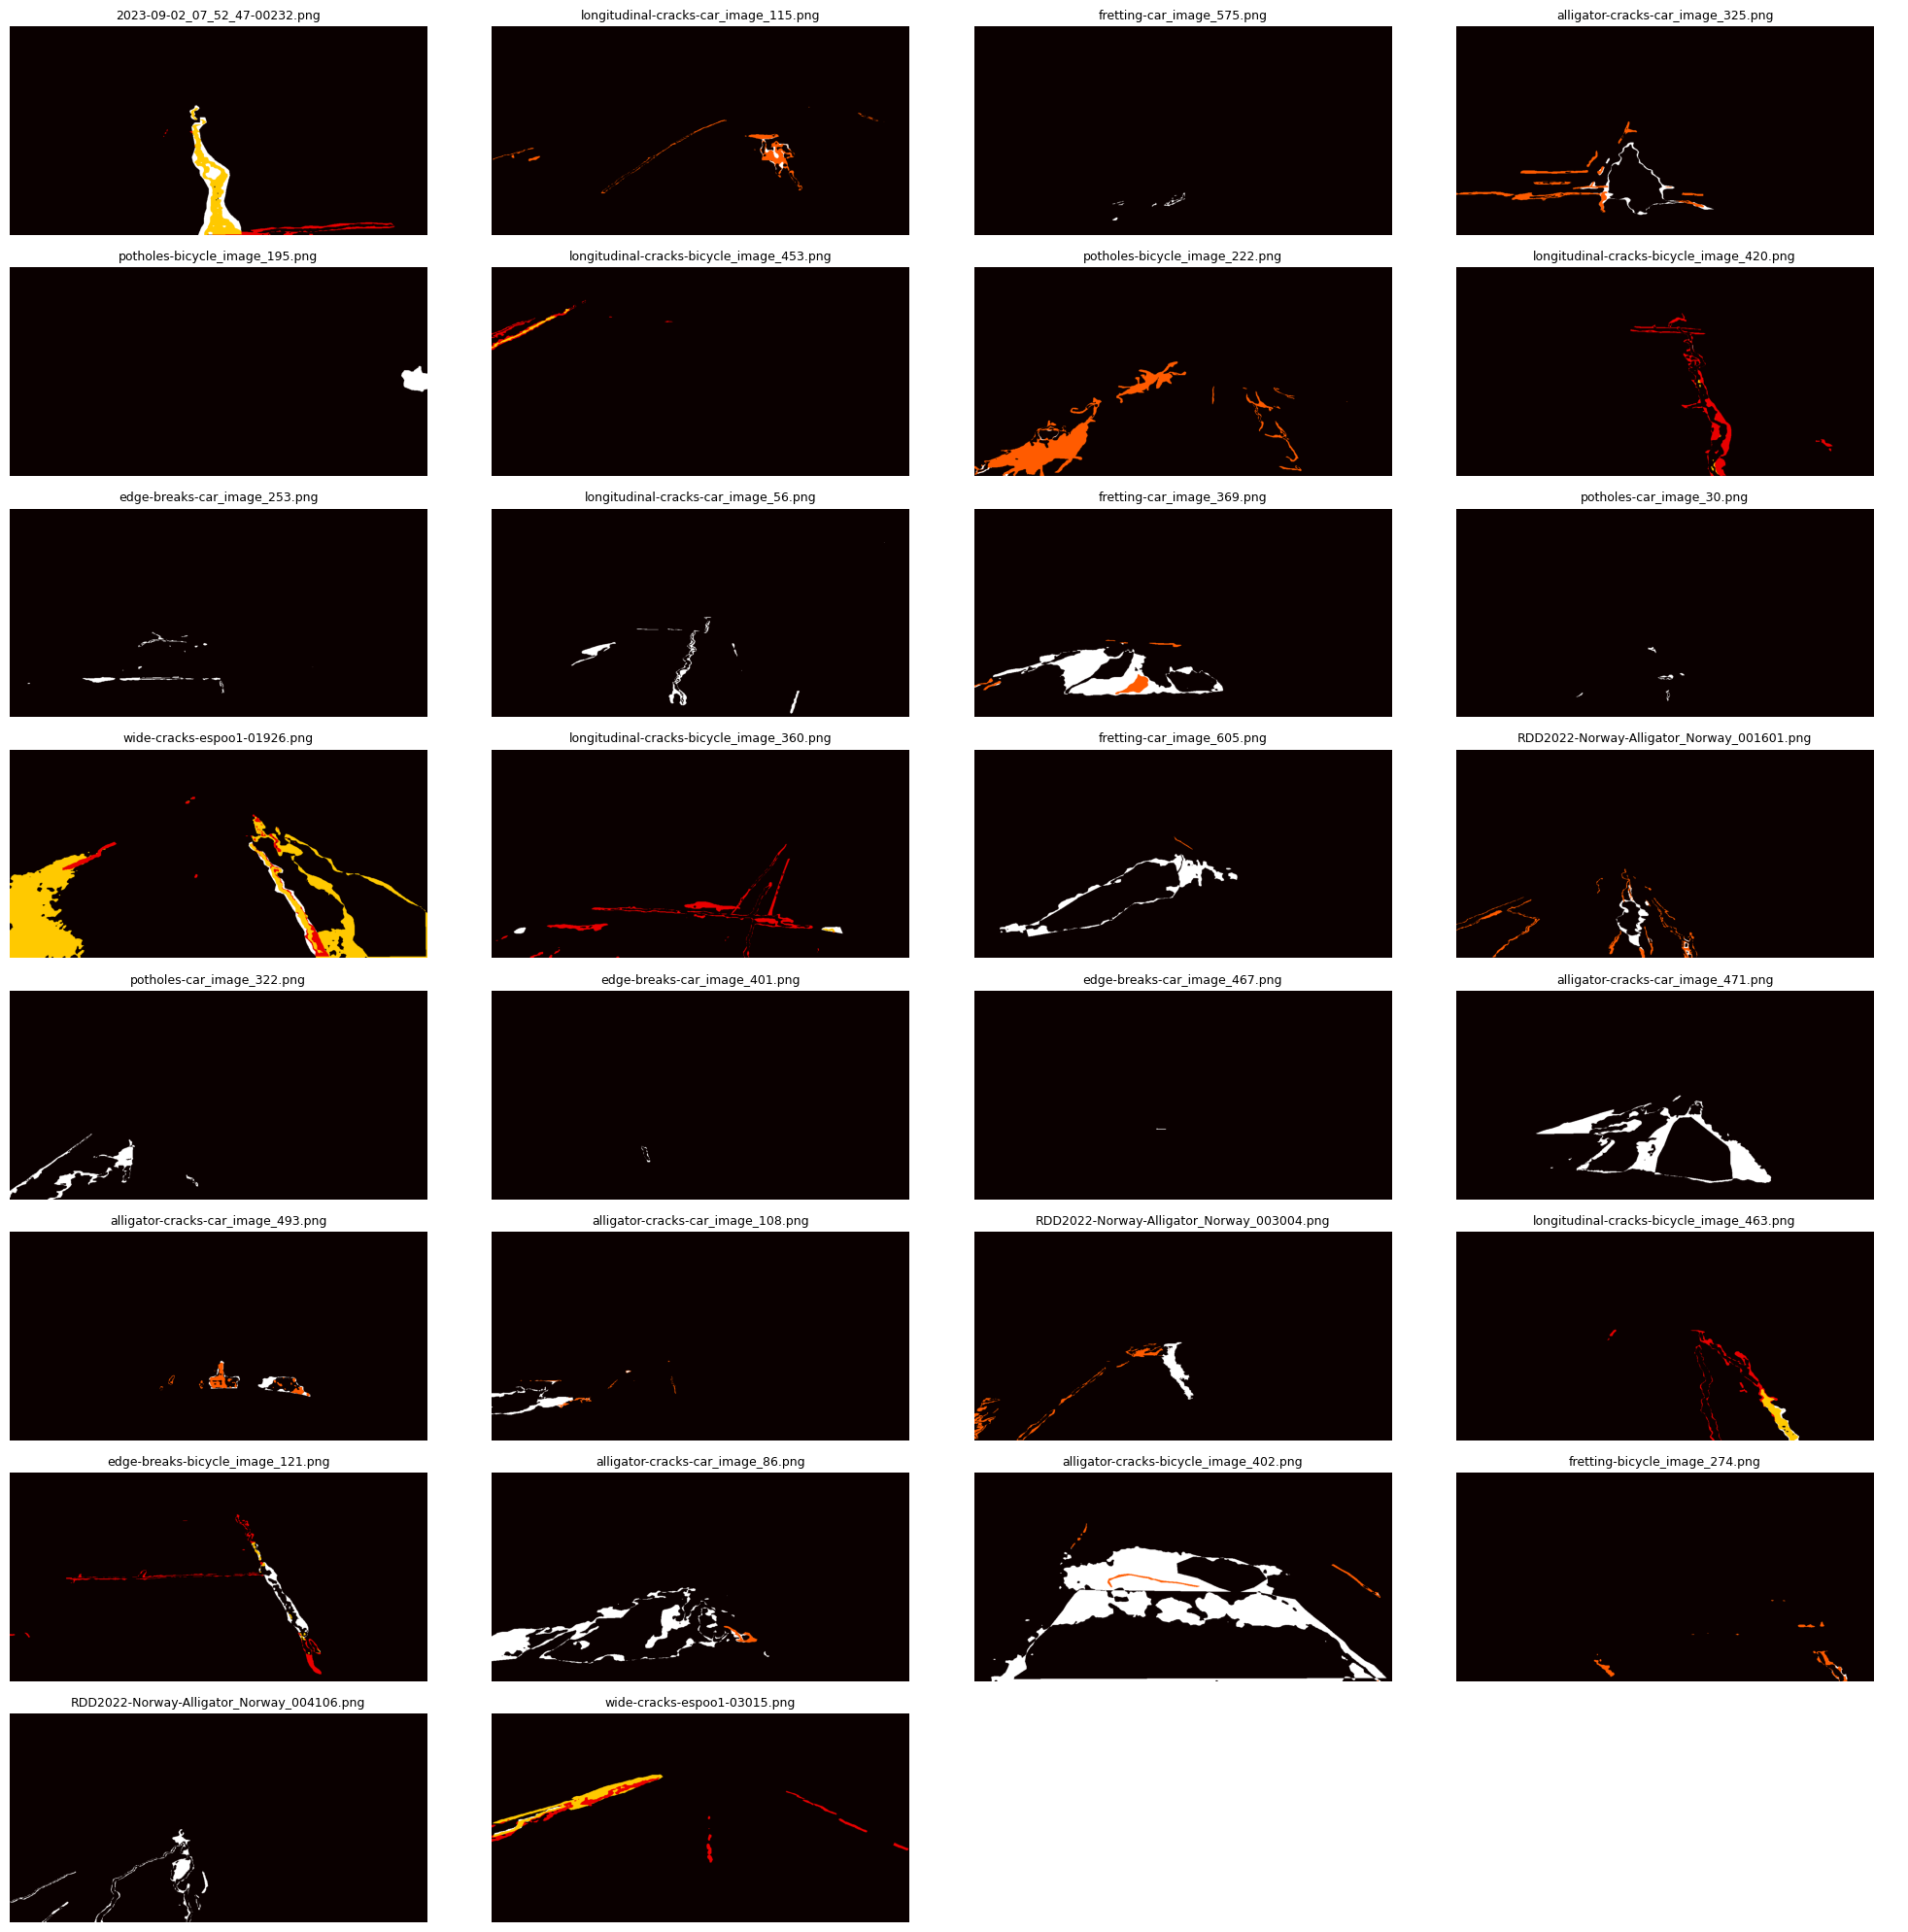

In [35]:
MAX_SAMPLES = 30           # Total images to display
COLS = 4

def run_analysis_subplot():
    # 1. Get list of all prediction files
    pred_files = [f for f in os.listdir(PRED_DIR) if f.endswith(('.png', '.jpg'))]
    print(f"Found {len(pred_files)} prediction masks.")

    # 2. Setup Matplotlib Figure
    # Calculate rows dynamically: Ceiling of (Total / Cols)
  

    rows = math.ceil(min(len(pred_files), MAX_SAMPLES) / COLS)
    
    # --- FIX 1: ADJUST FIGURE HEIGHT ---
    # Changed multiplier from 4 to 2.5. 
    # Since your images are wide, we need less height per row.
    fig, axes = plt.subplots(rows, COLS, figsize=(20, 2.5 * rows))
    
    # --- FIX 2: TIGHTEN GAPS ---
    # wspace controls width gap, hspace controls height gap.
    # Setting these to near-zero removes the gaps between the images.
    plt.subplots_adjust(wspace=0.05, hspace=0.1)

    axes = axes.flatten()
    
    matched_count = 0
    
    for filename in pred_files:
        if matched_count >= MAX_SAMPLES:
            break

        gt_path = os.path.join(GT_DIR, filename)
        pred_path = os.path.join(PRED_DIR, filename)

        if os.path.exists(gt_path):
            # Load images as Grayscale
            pred_img = cv2.imread(pred_path, 0)
            gt_img = cv2.imread(gt_path, 0)

            # Resize check
            if pred_img.shape != gt_img.shape:
                pred_img = cv2.resize(pred_img, (gt_img.shape[1], gt_img.shape[0]), interpolation=cv2.INTER_NEAREST)

            # --- VISUALIZATION LOGIC ---
            # Create a difference map (Absolute difference)
            # This highlights pixels where Pred differs from GT
            diff = cv2.absdiff(gt_img, pred_img)
            
            # Select the specific subplot axis
            ax = axes[matched_count]
            
            # Plot the difference heatmap
            # 'hot' or 'jet' colormaps are good for errors
            im = ax.imshow(diff, cmap='hot') 
            
            # Formatting the subplot
            ax.set_title(f"{filename}", fontsize=9)
            ax.axis('off') # Hide axis ticks for cleanliness

            matched_count += 1
        else:
            print(f"MISSING GT: {filename}")

    # 3. Cleanup
    # Hide any unused subplots (if you processed 28 images in a grid of 30)
    for i in range(matched_count, len(axes)):
        axes[i].axis('off')

    print(f"\nTotal Pairs Processed: {matched_count}")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_analysis_subplot()

Found 100 prediction masks.
Processing: 2023-09-02_07_52_47-00232.png


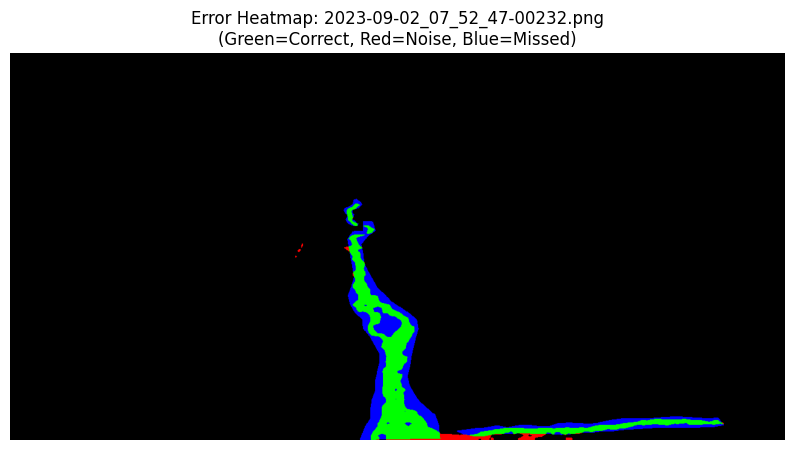

Processing: longitudinal-cracks-car_image_115.png


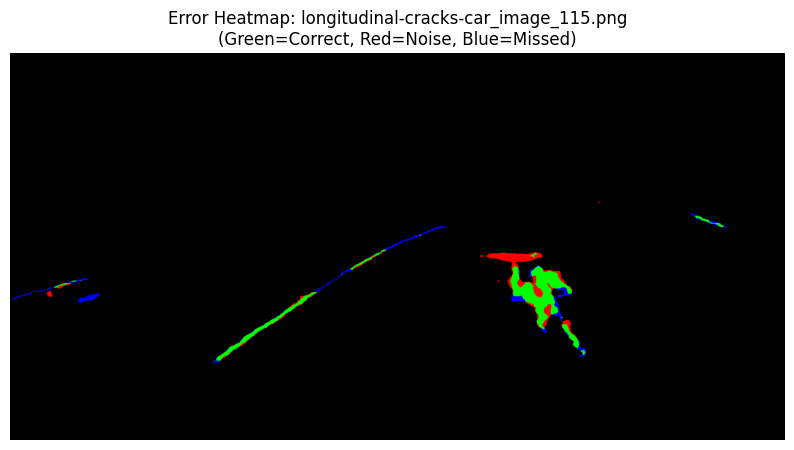

Processing: fretting-car_image_575.png


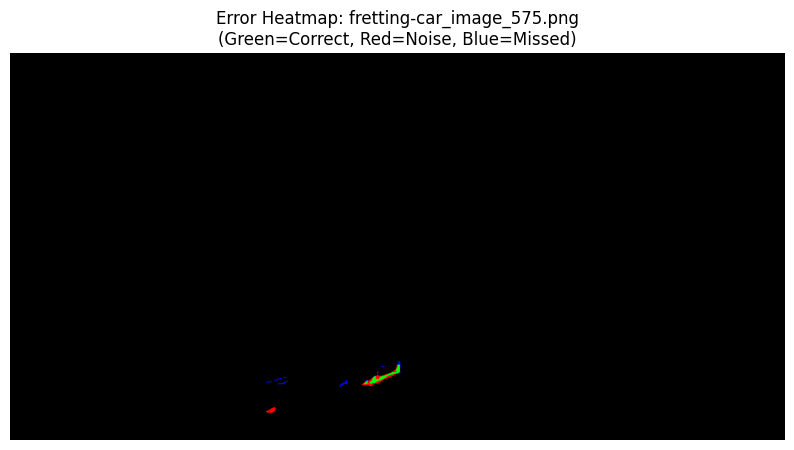

Processing: alligator-cracks-car_image_325.png


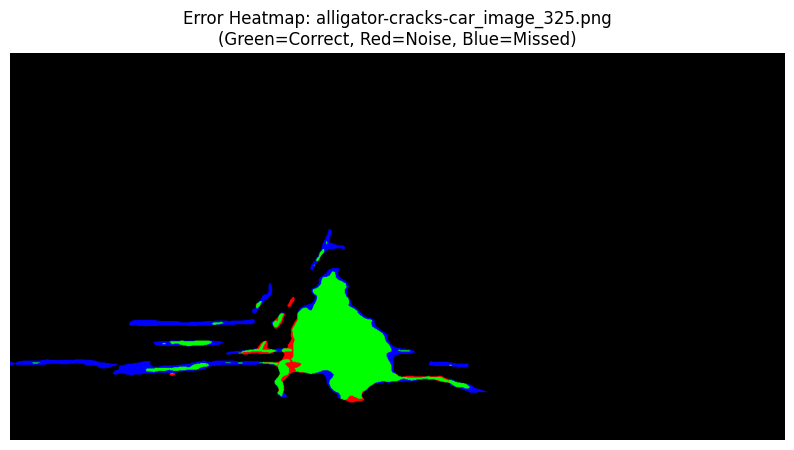

Processing: potholes-bicycle_image_195.png


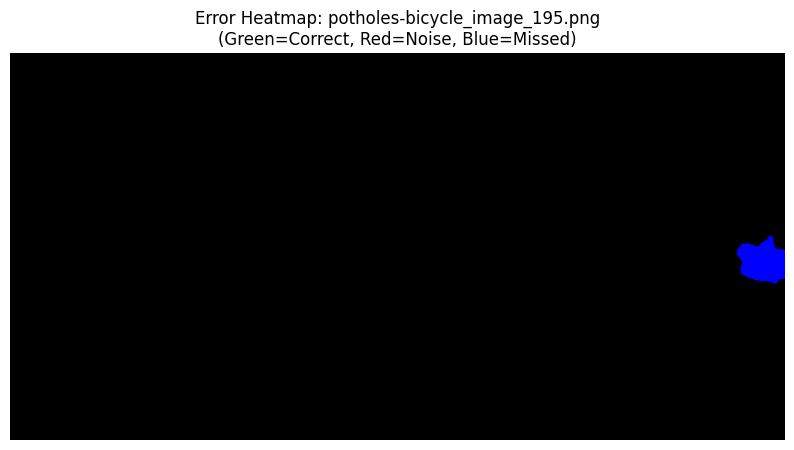

Processing: longitudinal-cracks-bicycle_image_453.png


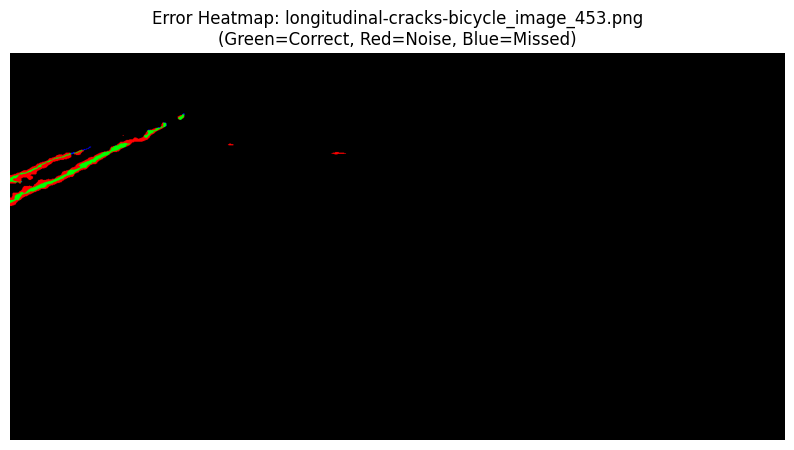

Processing: potholes-bicycle_image_222.png


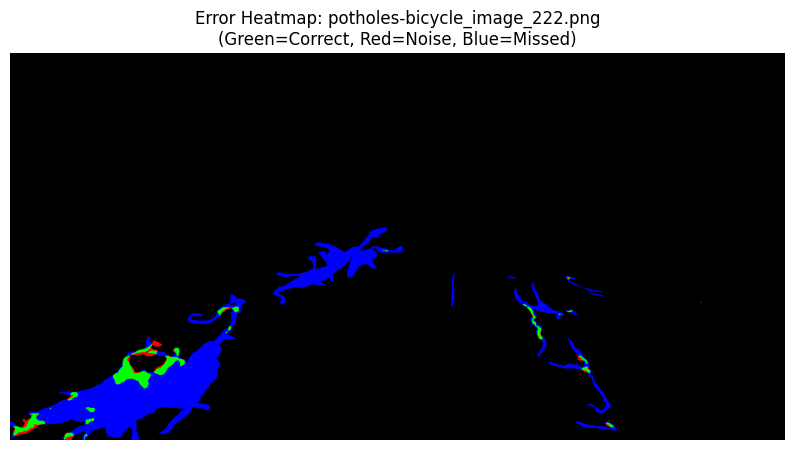

Processing: longitudinal-cracks-bicycle_image_420.png


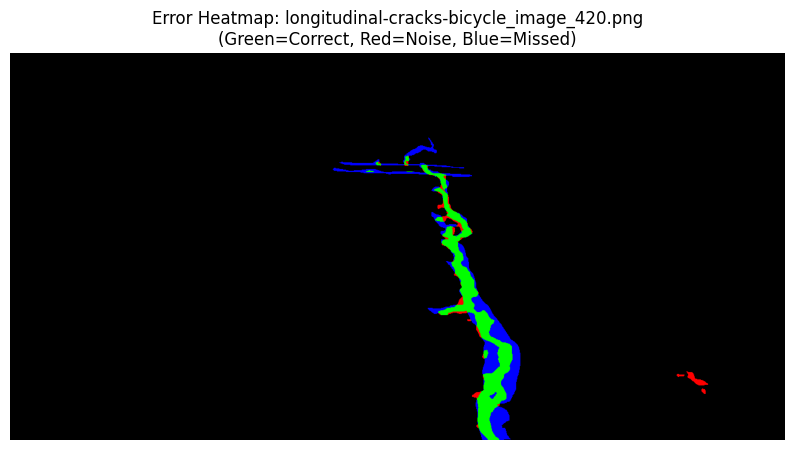

Processing: edge-breaks-car_image_253.png


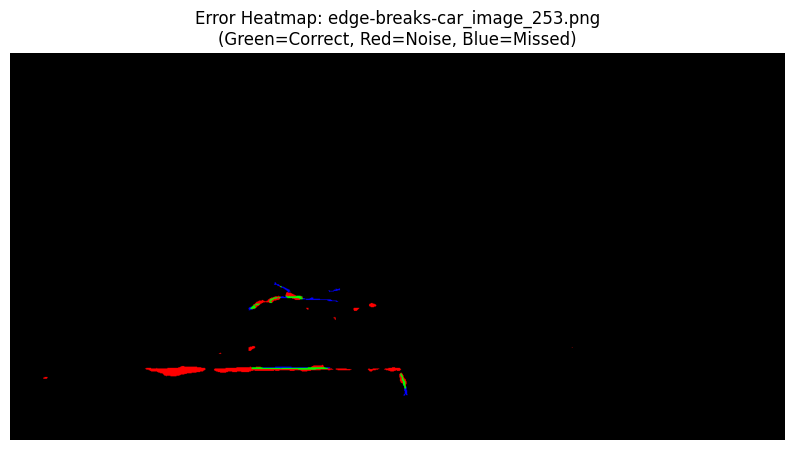

Processing: longitudinal-cracks-car_image_56.png


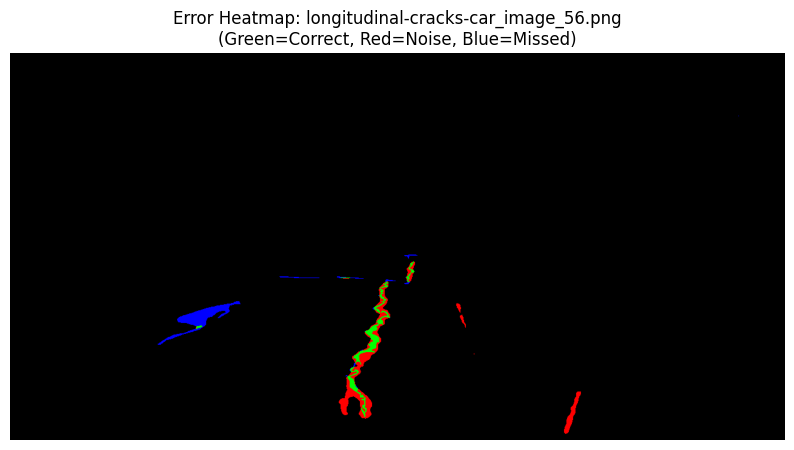

Processing: fretting-car_image_369.png


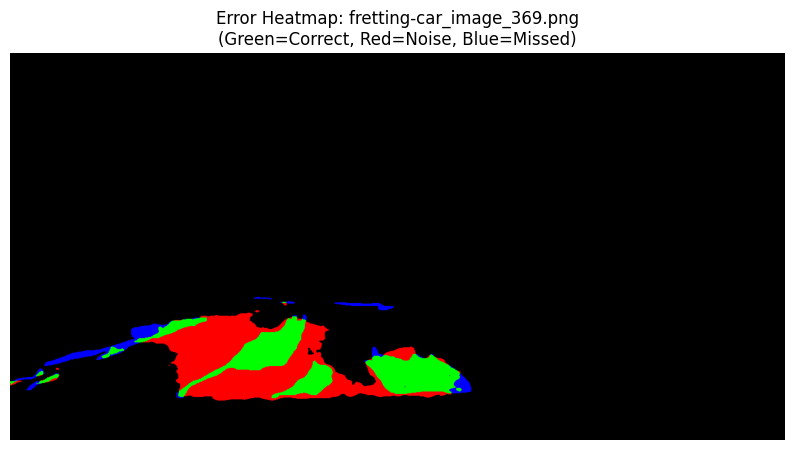

Processing: potholes-car_image_30.png


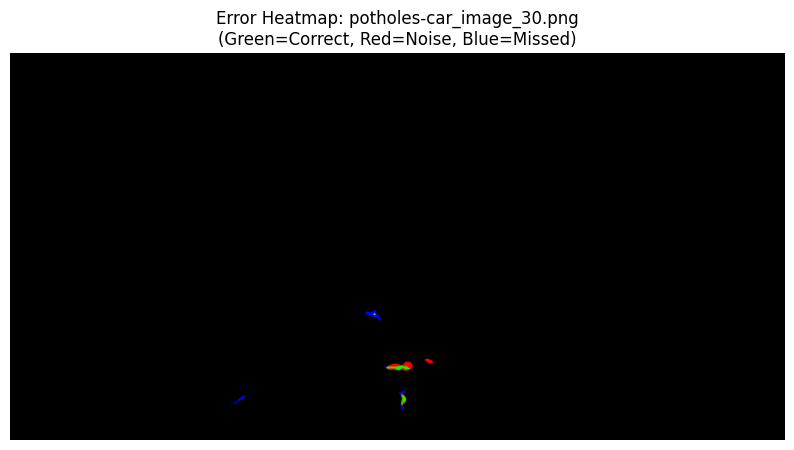

Processing: wide-cracks-espoo1-01926.png


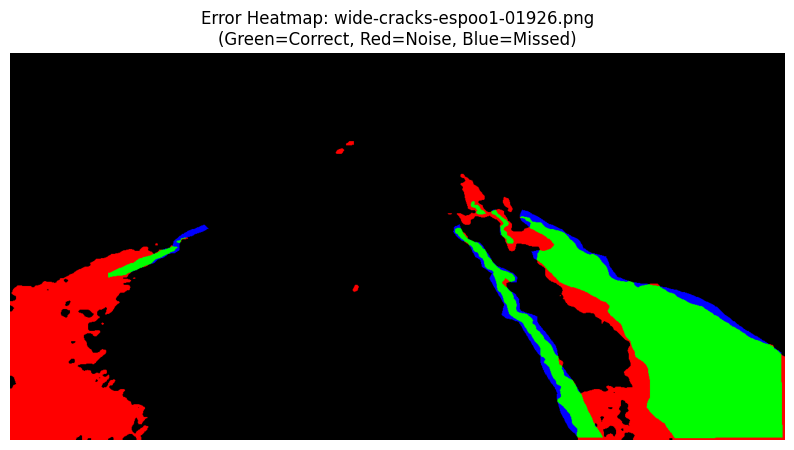

Processing: longitudinal-cracks-bicycle_image_360.png


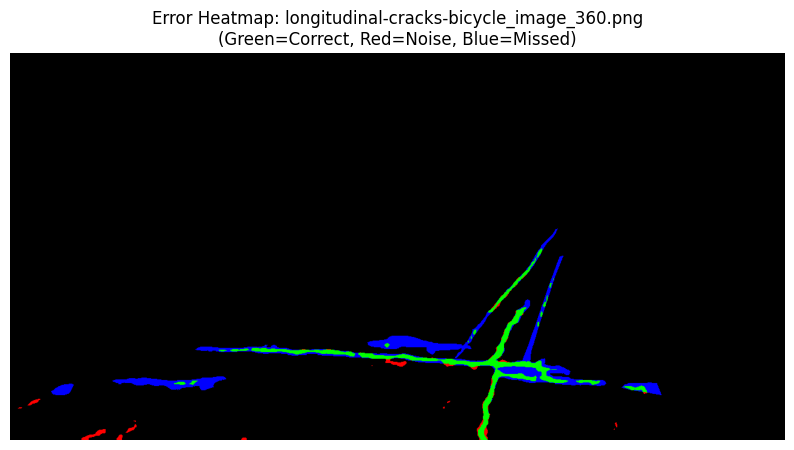

Processing: fretting-car_image_605.png


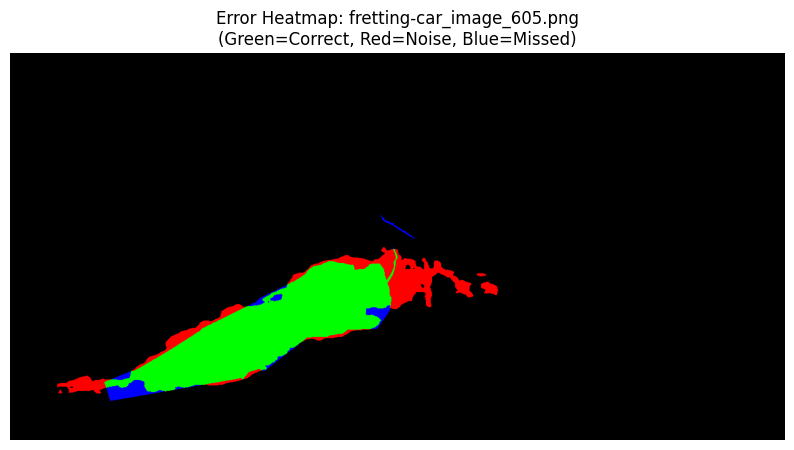

Processing: RDD2022-Norway-Alligator_Norway_001601.png


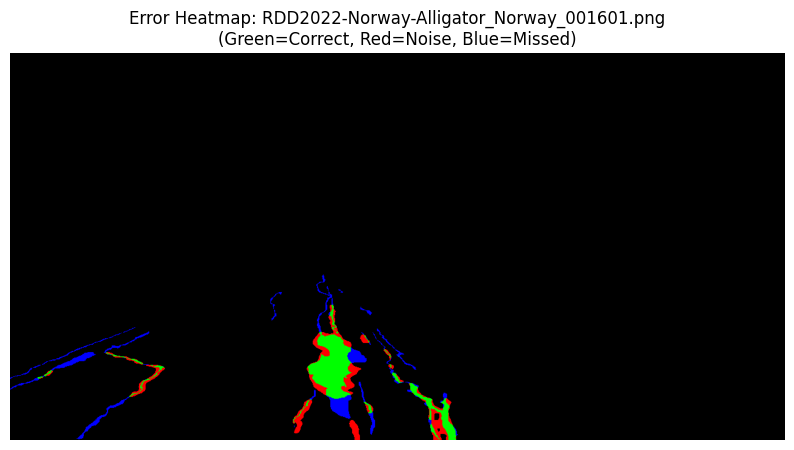

Processing: potholes-car_image_322.png


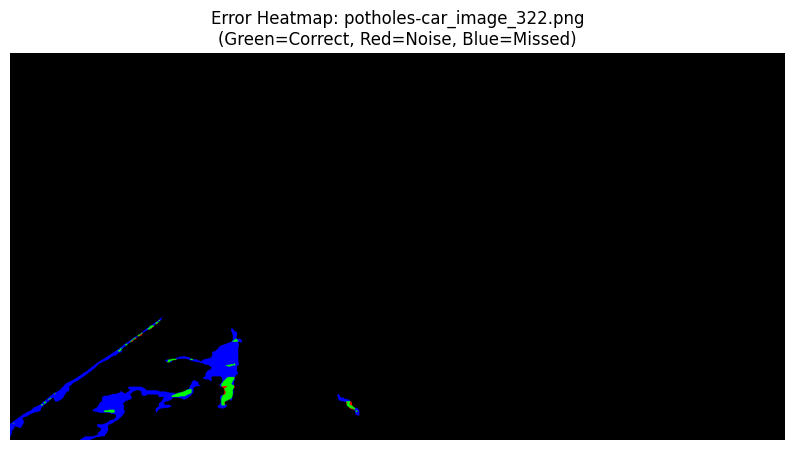

Processing: edge-breaks-car_image_401.png


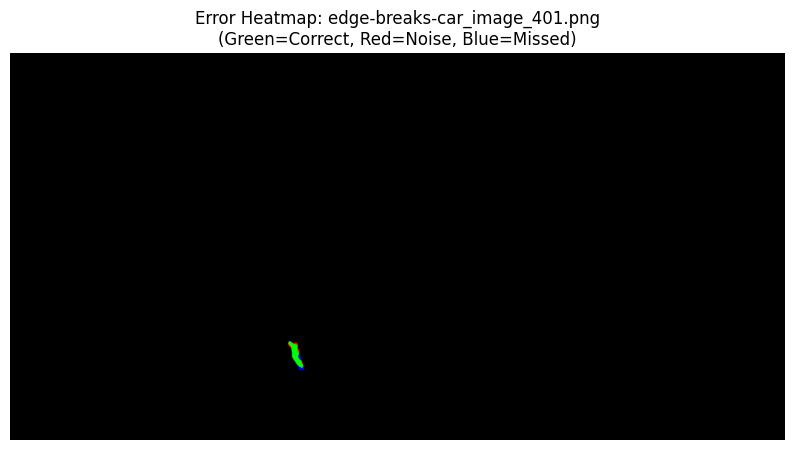

Processing: edge-breaks-car_image_467.png


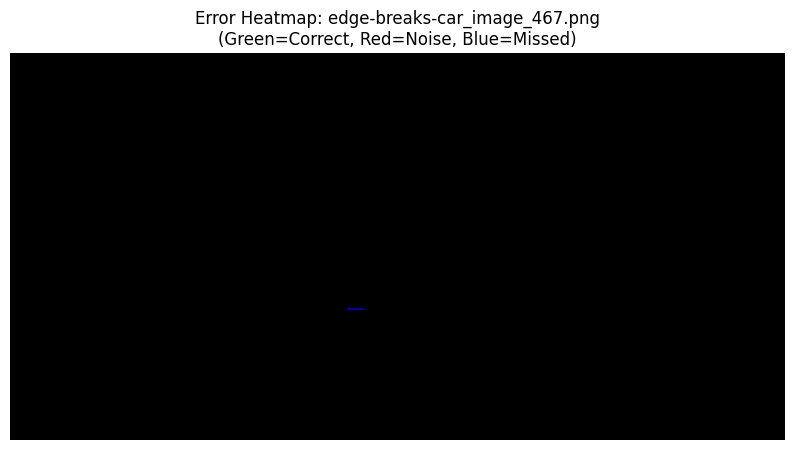

Processing: alligator-cracks-car_image_471.png


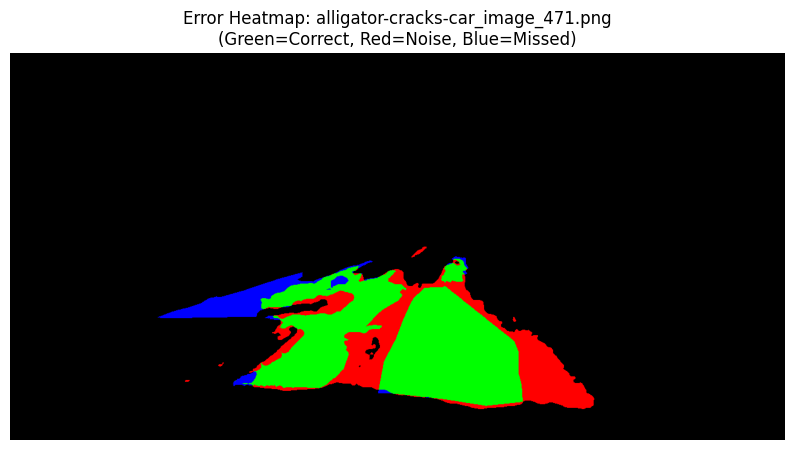

Processing: alligator-cracks-car_image_493.png


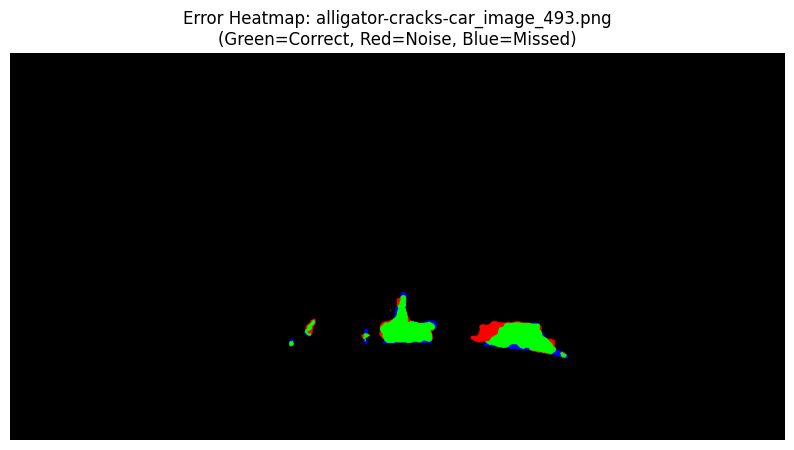

Processing: alligator-cracks-car_image_108.png


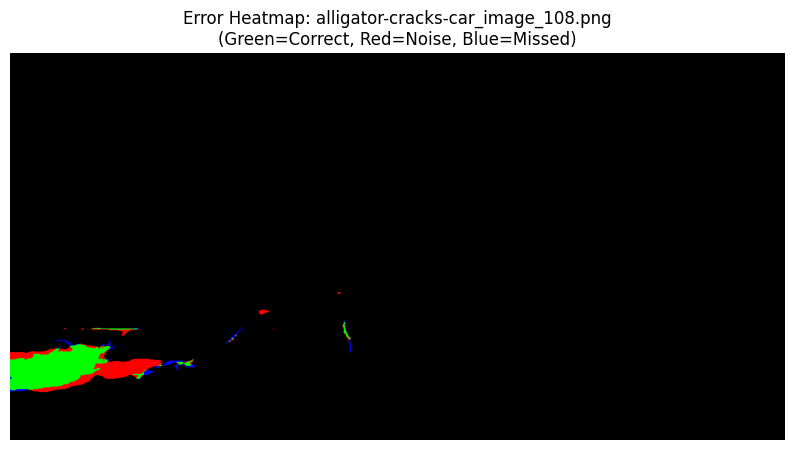

Processing: RDD2022-Norway-Alligator_Norway_003004.png


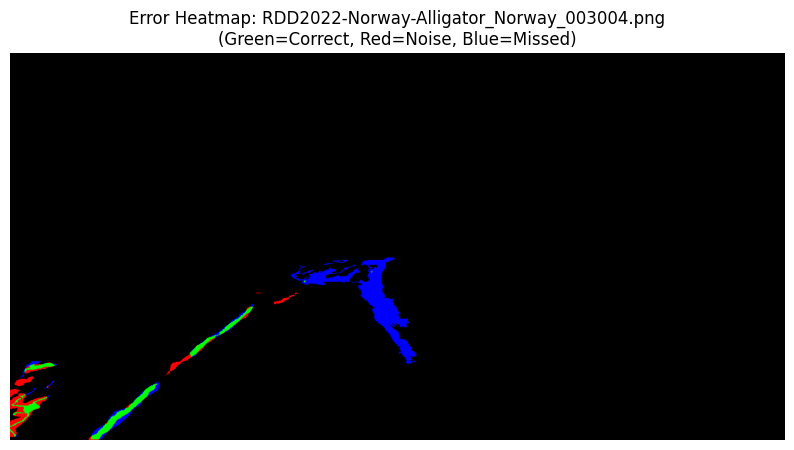

Processing: longitudinal-cracks-bicycle_image_463.png


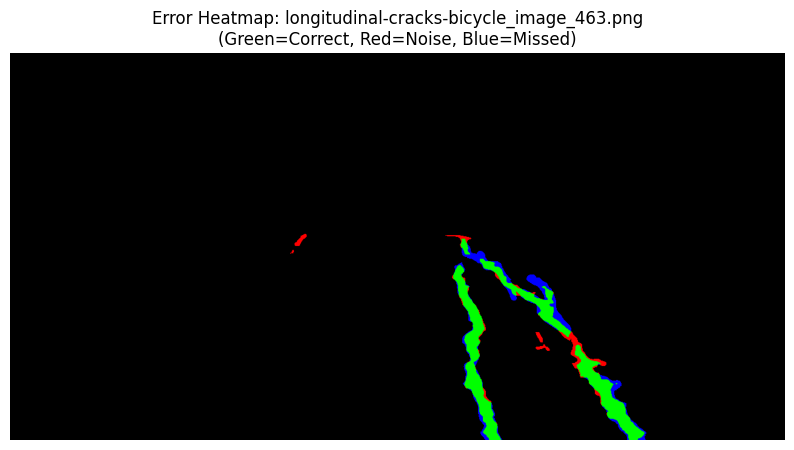

Processing: edge-breaks-bicycle_image_121.png


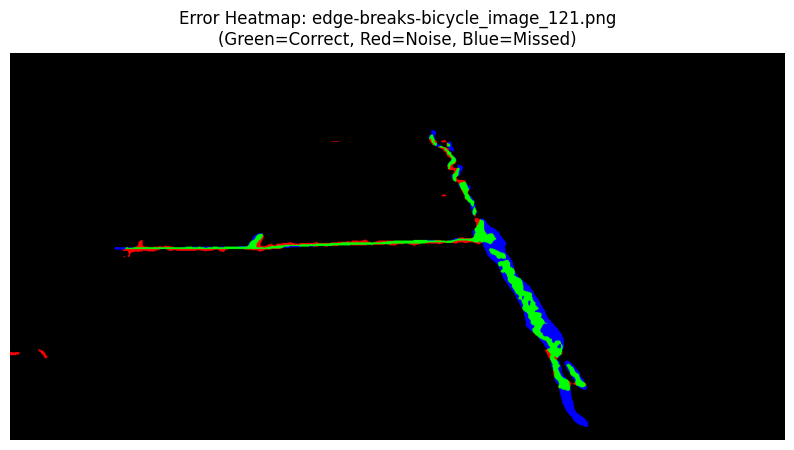

Processing: alligator-cracks-car_image_86.png


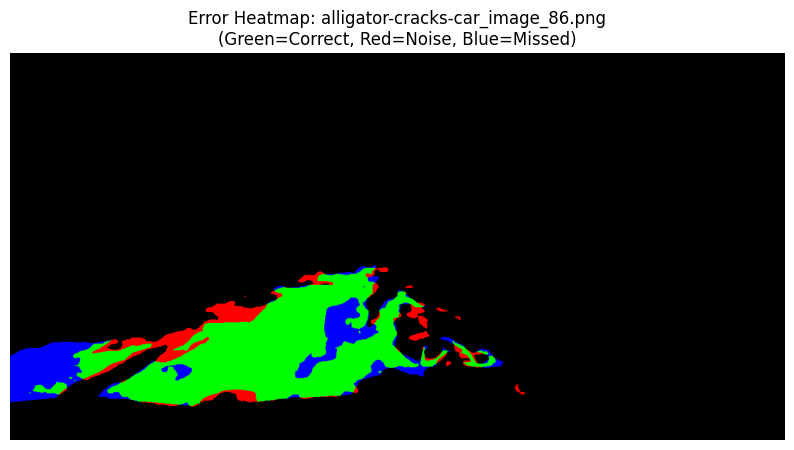

Processing: alligator-cracks-bicycle_image_402.png


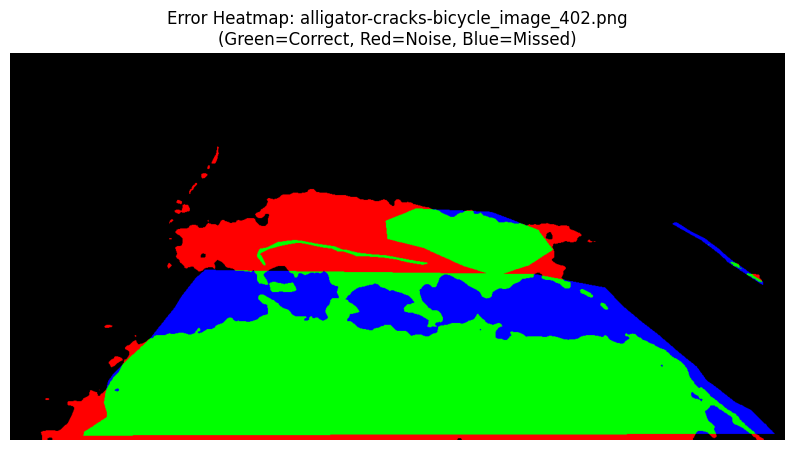

Processing: fretting-bicycle_image_274.png


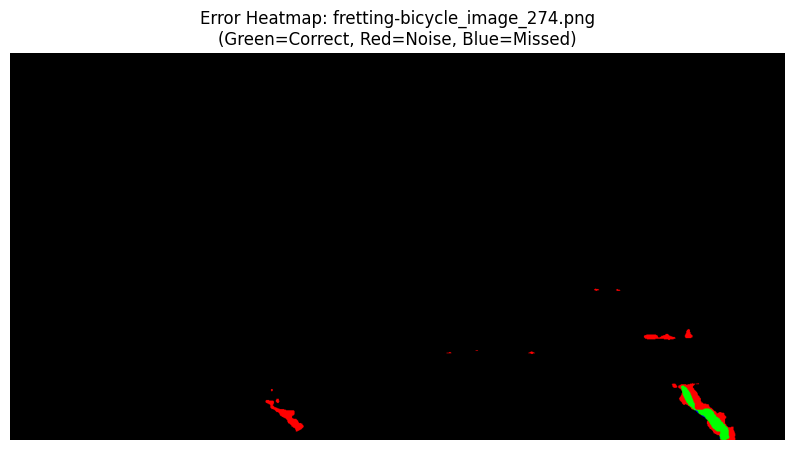

Processing: RDD2022-Norway-Alligator_Norway_004106.png


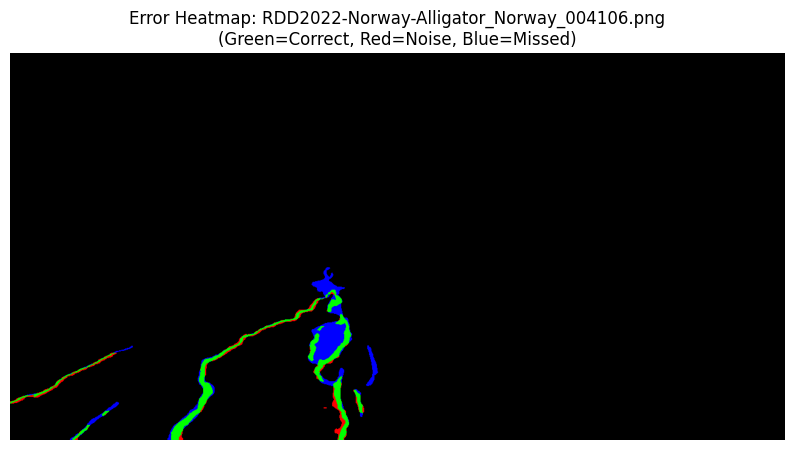

Processing: wide-cracks-espoo1-03015.png


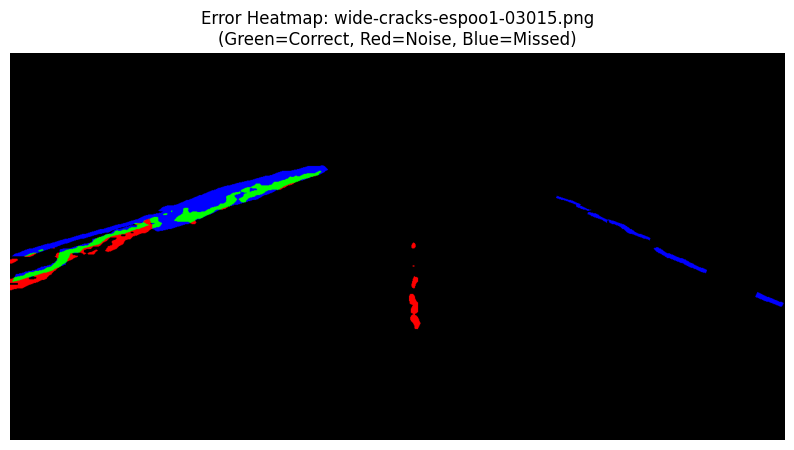

Stopping after 3 examples. Remove the 'break' in code to run all.

Total Pairs Processed: 30


In [27]:
# Obtain images to compare

def run_analysis():
    # Get list of all prediction files
    pred_files = [f for f in os.listdir(PRED_DIR) if f.endswith(('.png', '.jpg'))]
    
    print(f"Found {len(pred_files)} prediction masks.")
    
    matched_count = 0
    
    for filename in pred_files:
        # Construct the full path to the prediction
        pred_path = os.path.join(PRED_DIR, filename)
        
        # Construct the expected path to the Ground Truth
        # (Assuming filenames are identical. If not, we can adjust logic here)
        gt_path = os.path.join(GT_DIR, filename)

        
        # Check if the matching ground truth actually exists
        if os.path.exists(gt_path):
            matched_count += 1
            print(f"Processing: {filename}")
            
            # Load images as Grayscale
            # '0' flag loads as grayscale directly
            pred_img = cv2.imread(pred_path, 0)
            gt_img = cv2.imread(gt_path, 0)
            
            # Resize if necessary (sanity check)
            if pred_img.shape != gt_img.shape:
                print(f"Warning: Size mismatch for {filename}. Resizing pred to match GT.")
                pred_img = cv2.resize(pred_img, (gt_img.shape[1], gt_img.shape[0]), interpolation=cv2.INTER_NEAREST)

            # Run Visualization
            generate_error_heatmap(gt_img, pred_img, filename)
            
            # Stop after 3 images so you don't get flooded (remove break to run all)
            if matched_count >= 30:
                print("Stopping after 3 examples. Remove the 'break' in code to run all.")
                break
        else:
            print(f"MISSING GT: Could not find match for {filename}")

    print(f"\nTotal Pairs Processed: {matched_count}")

run_analysis()

In [ ]:


def visualize_crack_differences(y_true, y_pred, image_path=None):
    """
    y_true: Ground truth mask (2D array, 0 or 1)
    y_pred: Predicted mask (2D array, 0 or 1)
    image_path: Optional path to original image for overlay
    """
    
    # Ensure inputs are binary (0s and 1s)
    y_true = (y_true > 0).astype(np.uint8)
    y_pred = (y_pred > 0).astype(np.uint8)

    # 1. Calculate TP, FP, FN
    # True Positive (Intersection): Both refer to crack
    tp = np.logical_and(y_pred == 1, y_true == 1)
    
    # False Positive (Over-prediction): Pred is 1, Truth is 0
    fp = np.logical_and(y_pred == 1, y_true == 0)
    
    # False Negative (Missed): Pred is 0, Truth is 1
    fn = np.logical_and(y_pred == 0, y_true == 1)

    # 2. Create the RGB Error Map
    # Initialize a black image with 3 channels (R, G, B)
    h, w = y_true.shape
    error_map = np.zeros((h, w, 3), dtype=np.uint8)

    # Assign Colors
    # Green for Correct (TP)
    error_map[tp] = [0, 255, 0] 
    # Red for Noise/Over-prediction (FP)
    error_map[fp] = [255, 0, 0]
    # Blue for Missed Cracks (FN)
    error_map[fn] = [0, 0, 255]

    # 3. Visualization
    plt.figure(figsize=(15, 5))

    # Plot 1: The Error Map alone (Best for analyzing structure)
    plt.subplot(1, 2, 1)
    plt.imshow(error_map)
    plt.title("Difference Map\nGreen=Correct, Red=Extra, Blue=Missed")
    plt.axis('off')

    # Plot 2: Overlay on original image (if provided)
    if image_path:
        original_img = cv2.imread(image_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 2, 2)
        plt.imshow(original_img)
        # Overlay the error map with transparency (alpha=0.5)
        plt.imshow(error_map, alpha=0.5)
        plt.title("Overlay on Road Surface")
        plt.axis('off')

    plt.show()

# Example Usage:
# visualize_crack_differences(ground_truth_mask, predicted_mask, 'road_image.jpg')